<a href="https://colab.research.google.com/github/Sayeed92972/Projects/blob/main/Efficient_Frontier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

I have analyzed multiple stocks from different sectors to diversify my portfolio. The goal was to identify stocks that offered the highest Sharpe ratio during the specified time period. From this initial analysis, I selected the top 5 stocks for each portfolio and proceeded with the portfolio optimization as instructed.

In [2]:
#Create dataframe
#Tickers from https://finance.yahoo.com/
stocks_1=['NVDA','KO','ISP.MI','TSLA','WMT'] #stocks that picked during class
stocks_2=['NVDA','LLY','ISP.MI','XOM','RTX'] #stocks that picked by me

df_1=pd.DataFrame()
for i in stocks_1:
  df_1[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
df_1=df_1.dropna()
df_1


/tmp/ipykernel_4912/2244464979.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_1[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4912/2244464979.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_1[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4912/2244464979.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_1[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4912/2244464979.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_1[i]=yf.download(i, start ='2021-01-01', end='202

,NVDA,KO,ISP.MI,TSLA,WMT
Date,,,,,
2021-01-04,13.076016,45.081982,1.267847,243.256668,45.454311
2021-01-05,13.366435,44.586380,1.254006,245.036667,45.212353
2021-01-06,12.578444,43.167957,1.296463,251.993332,45.494640
2021-01-07,13.305861,42.689449,1.309639,272.013336,45.491531
2021-01-08,13.238801,43.646465,1.300988,293.339996,45.485321
...,...,...,...,...,...
2025-12-22,183.680054,69.730530,5.882000,488.730011,112.155350
2025-12-23,189.199768,69.392860,5.871000,485.559998,110.462059
2025-12-29,188.209808,69.680878,5.838000,459.640015,112.085617


In [3]:
df_2=pd.DataFrame()
for i in stocks_2:
  df_2[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
df_2=df_2.dropna()
df_2

/tmp/ipykernel_4912/1181943228.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_2[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4912/1181943228.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_2[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4912/1181943228.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_2[i]=yf.download(i, start ='2021-01-01', end='2026-01-04')['Close']     #year-day-month
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4912/1181943228.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_2[i]=yf.download(i, start ='2021-01-01', end='202

,NVDA,LLY,ISP.MI,XOM,RTX
Date,,,,,
2021-01-04,13.076016,156.524872,1.267847,33.466640,60.811340
2021-01-05,13.366435,157.300369,1.254006,35.079479,61.691109
2021-01-06,12.578444,155.408844,1.296463,35.974621,62.455372
2021-01-07,13.305861,156.836975,1.309639,36.256863,62.011036
2021-01-08,13.238801,157.385529,1.300988,36.660084,62.082130
...,...,...,...,...,...
2025-12-22,183.680054,1072.839478,5.882000,116.576447,185.065308
2025-12-23,189.199768,1068.015869,5.871000,117.829529,185.145050
2025-12-29,188.209808,1075.081787,5.838000,118.924744,183.809494


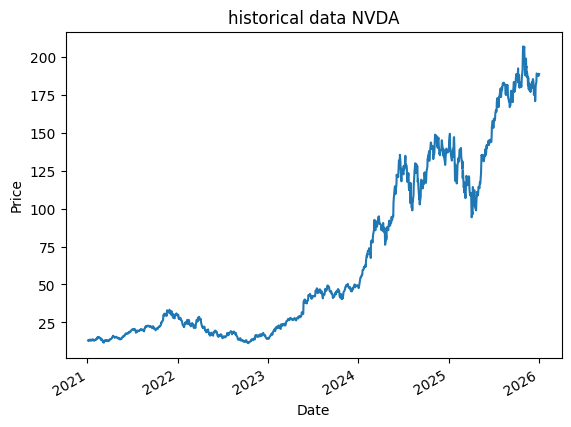

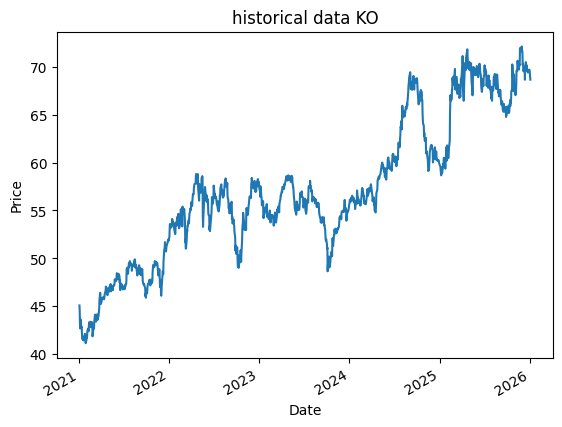

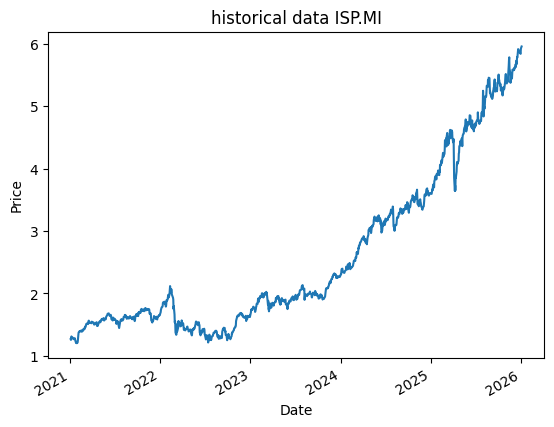

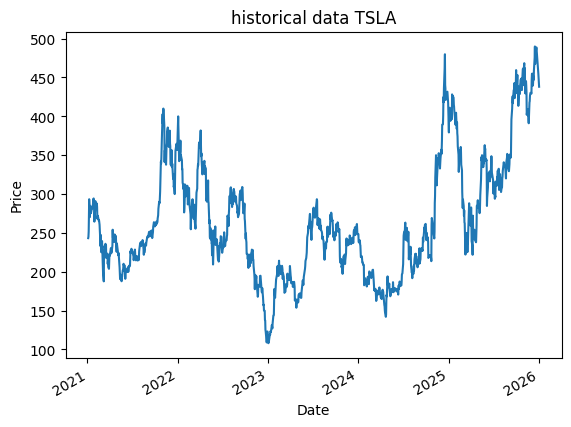

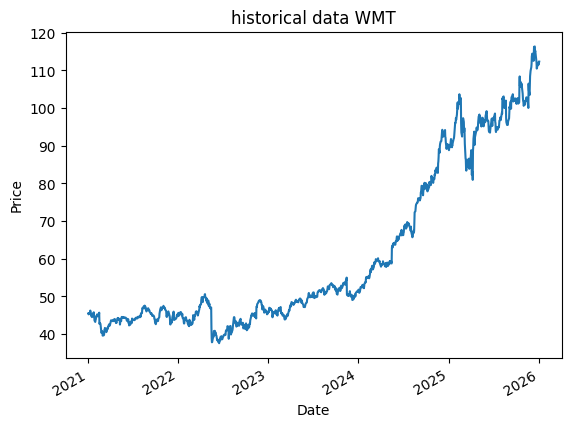

In [4]:
#plot historical data
for i in stocks_1:
  df_1[i].plot()
  plt.title("historical data "+ i)
  plt.xlabel("Date")
  plt.ylabel("Price")
  plt.show()


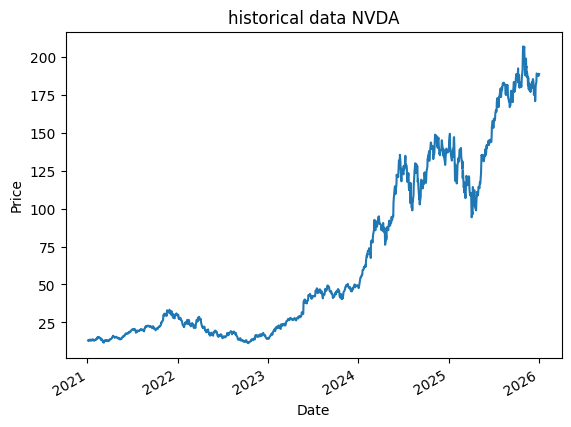

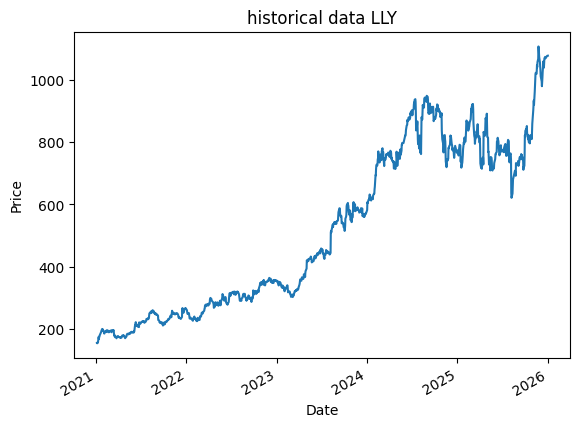

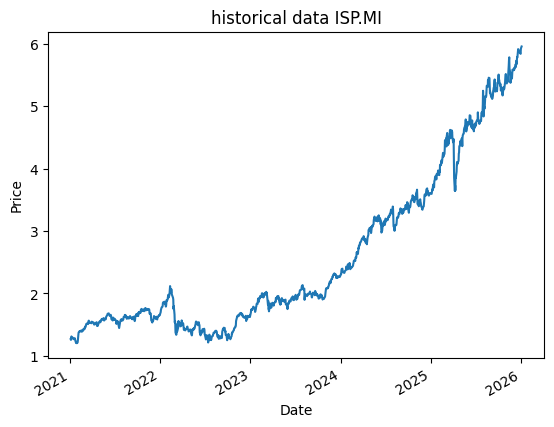

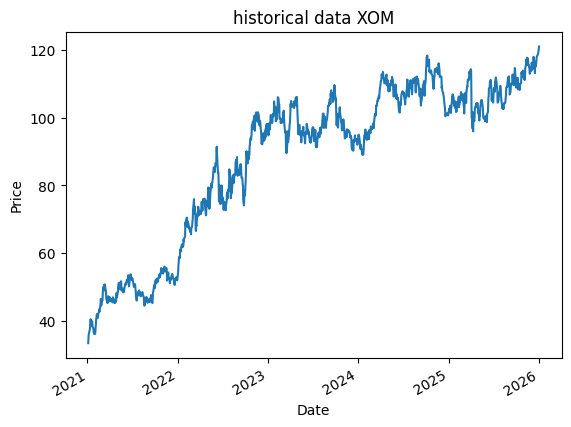

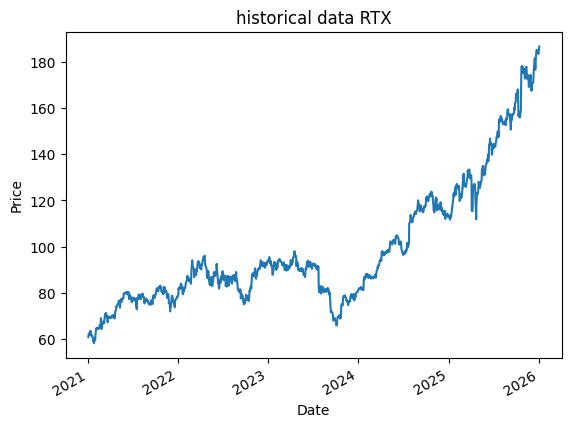

In [5]:
#plot historical data
for i in stocks_2:
  df_2[i].plot()
  plt.title("historical data "+ i)
  plt.xlabel("Date")
  plt.ylabel("Price")
  plt.show()

In [6]:
#return
r_1=np.log(df_1/df_1.shift()).dropna()
r_1


,NVDA,KO,ISP.MI,TSLA,WMT
Date,,,,,
2021-01-05,0.021967,-0.011054,-0.010977,0.007291,-0.005337
2021-01-06,-0.060762,-0.032330,0.033296,0.027995,0.006224
2021-01-07,0.056220,-0.011147,0.010112,0.076448,-0.000068
2021-01-08,-0.005053,0.022170,-0.006628,0.075481,-0.000137
2021-01-11,0.025635,-0.017378,-0.006260,-0.081442,0.004491
...,...,...,...,...,...
2025-12-22,0.014808,0.002139,-0.005426,0.015527,-0.015510
2025-12-23,0.029608,-0.004854,-0.001872,-0.006507,-0.015213
2025-12-29,-0.005246,0.004142,-0.005637,-0.054859,0.014591


In [7]:
#return
r_2=np.log(df_2/df_2.shift()).dropna()
r_2

,NVDA,LLY,ISP.MI,XOM,RTX
Date,,,,,
2021-01-05,0.021967,0.004942,-0.010977,0.047067,0.014364
2021-01-06,-0.060762,-0.012098,0.033296,0.025197,0.012312
2021-01-07,0.056220,0.009148,0.010112,0.007815,-0.007140
2021-01-08,-0.005053,0.003492,-0.006628,0.011060,0.001146
2021-01-11,0.025635,0.110969,-0.006260,0.029904,-0.000859
...,...,...,...,...,...
2025-12-22,0.014808,0.004693,-0.005426,0.012434,0.019963
2025-12-23,0.029608,-0.004506,-0.001872,0.010692,0.000431
2025-12-29,-0.005246,0.006594,-0.005637,0.009252,-0.007240


In [8]:
annual_return_1=r_1.mean()*252
annual_return_1.sort_values(ascending=False)

,0
NVDA,0.544834
ISP.MI,0.315679
WMT,0.184582
TSLA,0.120034
KO,0.085804


In [9]:
annual_return_2=r_2.mean()*252
annual_return_2.sort_values(ascending=False)

,0
NVDA,0.544834
LLY,0.393497
ISP.MI,0.315679
XOM,0.262280
RTX,0.228810


In [10]:
annual_variance_1=r_1.var()*252
annual_std_1=np.sqrt(annual_variance_1)

annual_variance_1.sort_values(ascending=False)


,0
TSLA,0.370060
NVDA,0.271343
ISP.MI,0.075062
WMT,0.044607
KO,0.025516


In [11]:
annual_variance_2=r_2.var()*252
annual_std_2=np.sqrt(annual_variance_2)

annual_variance_2.sort_values(ascending=False)


,0
NVDA,0.271343
LLY,0.100694
ISP.MI,0.075062
XOM,0.074953
RTX,0.058275


In [12]:
#var-cov matrix
sigma_1=r_1.cov()*252
sigma_1

,NVDA,KO,ISP.MI,TSLA,WMT
NVDA,0.271343,0.001041,0.024784,0.149428,0.013237
KO,0.001041,0.025516,0.005614,0.003066,0.011699
ISP.MI,0.024784,0.005614,0.075062,0.018157,0.003232
TSLA,0.149428,0.003066,0.018157,0.370060,0.022463
WMT,0.013237,0.011699,0.003232,0.022463,0.044607


In [13]:
#var-cov matrix
sigma_2=r_2.cov()*252
sigma_2

,NVDA,LLY,ISP.MI,XOM,RTX
NVDA,0.271343,0.030575,0.024784,0.012225,0.024692
LLY,0.030575,0.100694,-0.000904,0.006550,0.011451
ISP.MI,0.024784,-0.000904,0.075062,0.013139,0.014168
XOM,0.012225,0.006550,0.013139,0.074953,0.024392
RTX,0.024692,0.011451,0.014168,0.024392,0.058275


In [14]:
#correlation matrix
correlation_matrix_1=r_1.corr()
correlation_matrix_1


,NVDA,KO,ISP.MI,TSLA,WMT
NVDA,1.000000,0.012507,0.173664,0.471559,0.120320
KO,0.012507,1.000000,0.128274,0.031554,0.346765
ISP.MI,0.173664,0.128274,1.000000,0.108941,0.055854
TSLA,0.471559,0.031554,0.108941,1.000000,0.174834
WMT,0.120320,0.346765,0.055854,0.174834,1.000000


In [15]:
#correlation matrix
correlation_matrix_2=r_2.corr()
correlation_matrix_2


,NVDA,LLY,ISP.MI,XOM,RTX
NVDA,1.000000,0.184972,0.173664,0.085723,0.196365
LLY,0.184972,1.000000,-0.010403,0.075395,0.149481
ISP.MI,0.173664,-0.010403,1.000000,0.175171,0.214213
XOM,0.085723,0.075395,0.175171,1.000000,0.369075
RTX,0.196365,0.149481,0.214213,0.369075,1.000000


In [16]:
#optimization portfolio library
#https://pyportfolioopt.readthedocs.io/en/latest/

!pip install PyPortfolioOpt
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import plotting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 802.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 1.2 MB/s eta 0:00:00


/tmp/ipykernel_4912/4038510372.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(txt, (annual_std_1[i], annual_return_1[i]))


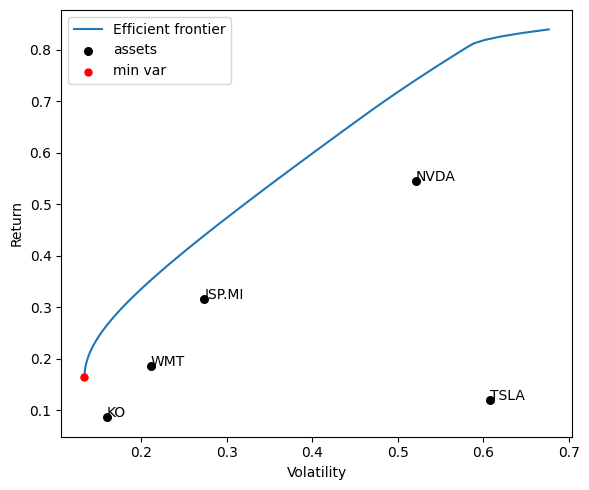

In [17]:
#Efficient Frontier

ef_1 = EfficientFrontier(annual_return_1,sigma_1, weight_bounds=(-1 , 1)) #bounds (0,1) or (-1,1)

fig, ax = plt.subplots(figsize=(6, 5))
plotting.plot_efficient_frontier(ef_1, ax=ax, show_assets=True,verbose=True)

ef_1.efficient_return(-1.0)
ret_min, std_min, _ = ef_1.portfolio_performance()
ax.scatter(std_min, ret_min, marker=".", s=100, c="r", label='min var',zorder=2)

for i, txt in enumerate(stocks_1):
    ax.annotate(txt, (annual_std_1[i], annual_return_1[i]))

ax.legend(loc="upper left")
plt.show()


/tmp/ipykernel_4912/2150933179.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(txt, (annual_std_2[i], annual_return_2[i]))


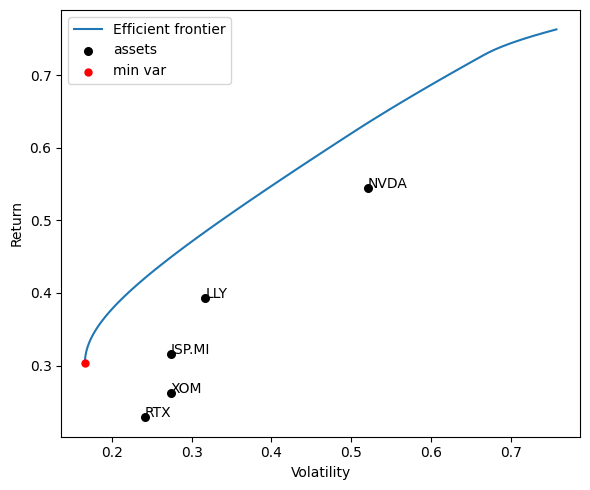

In [18]:
#Efficient Frontier

ef_2 = EfficientFrontier(annual_return_2,sigma_2, weight_bounds=(-1 , 1)) #bounds (0,1) or (-1,1)

fig, ax = plt.subplots(figsize=(6, 5))
plotting.plot_efficient_frontier(ef_2, ax=ax, show_assets=True,verbose=True)

ef_2.efficient_return(-1.0)
ret_min, std_min, _ = ef_2.portfolio_performance()
ax.scatter(std_min, ret_min, marker=".", s=100, c="r", label='min var',zorder=2)

for i, txt in enumerate(stocks_2):
    ax.annotate(txt, (annual_std_2[i], annual_return_2[i]))

ax.legend(loc="upper left")
plt.show()


In [19]:
weights_1 = ef_1.efficient_return(-1.0)  # find the portfolio min variance

cleaned_weights_1 = ef_1.clean_weights()
print(cleaned_weights_1)
ef_1.portfolio_performance(verbose=True)

OrderedDict({'NVDA': 0.03215, 'KO': 0.55588, 'ISP.MI': 0.17444, 'TSLA': 0.00832, 'WMT': 0.2292})
Expected annual return: 16.4%
Annual volatility: 13.4%
Sharpe Ratio: 1.22


(np.float64(0.16358771640533598),
 np.float64(0.1338033127824168),
 np.float64(1.222598402113951))

In [20]:
weights_2 = ef_2.efficient_return(-1.0)  # find the portfolio min variance

cleaned_weights_2 = ef_2.clean_weights()
print(cleaned_weights_2)
ef_2.portfolio_performance(verbose=True)

OrderedDict({'NVDA': 0.01704, 'LLY': 0.22778, 'ISP.MI': 0.27814, 'XOM': 0.21054, 'RTX': 0.26651})
Expected annual return: 30.3%
Annual volatility: 16.6%
Sharpe Ratio: 1.82


(np.float64(0.3029149516413578),
 np.float64(0.16624050418720884),
 np.float64(1.8221488988040808))

In [21]:
weights_1 = ef_1.efficient_return(0.3)  # find the portfolio composition setting the portfolio return

cleaned_weights_1 = ef_1.clean_weights()
print(cleaned_weights_1)
ef_1.portfolio_performance(verbose=True)

OrderedDict({'NVDA': 0.20663, 'KO': 0.13918, 'ISP.MI': 0.37359, 'TSLA': -0.08907, 'WMT': 0.36966})
Expected annual return: 30.0%
Annual volatility: 17.9%
Sharpe Ratio: 1.68


(np.float64(0.2999999858190387),
 np.float64(0.17864135400762746),
 np.float64(1.6793423196189476))

In [22]:
weights_2 = ef_2.efficient_return(0.3)  # find the portfolio composition setting the portfolio return

cleaned_weights_2 = ef_2.clean_weights()
print(cleaned_weights_2)
ef_2.portfolio_performance(verbose=True)

OrderedDict({'NVDA': 0.01704, 'LLY': 0.22778, 'ISP.MI': 0.27814, 'XOM': 0.21054, 'RTX': 0.26651})
Expected annual return: 30.3%
Annual volatility: 16.6%
Sharpe Ratio: 1.82


(np.float64(0.3029149516413586),
 np.float64(0.16624050418721004),
 np.float64(1.8221488988040728))

In [23]:
risk_free_rates = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05] # 0% to 5% risk-free rates

print("--- Portfolio 1 Performance with varying Risk-Free Rates ---")
for rfr in risk_free_rates:
    print(f"\nRisk-Free Rate: {rfr:.2%}")
    # Recalculate weights for minimum variance (Sharpe ratio is performance, not optimization objective here)
    ef_1.efficient_return(-1.0) # Ensure we are evaluating the same min_variance portfolio
    _, _, sharpe_ratio = ef_1.portfolio_performance(verbose=True, risk_free_rate=rfr)

print("\n--- Portfolio 2 Performance with varying Risk-Free Rates ---")
for rfr in risk_free_rates:
    print(f"\nRisk-Free Rate: {rfr:.2%}")
    # Recalculate weights for minimum variance (Sharpe ratio is performance, not optimization objective here)
    ef_2.efficient_return(-1.0) # Ensure we are evaluating the same min_variance portfolio
    _, _, sharpe_ratio = ef_2.portfolio_performance(verbose=True, risk_free_rate=rfr)

--- Portfolio 1 Performance with varying Risk-Free Rates ---

Risk-Free Rate: 0.00%
Expected annual return: 16.4%
Annual volatility: 13.4%
Sharpe Ratio: 1.22

Risk-Free Rate: 1.00%
Expected annual return: 16.4%
Annual volatility: 13.4%
Sharpe Ratio: 1.15

Risk-Free Rate: 2.00%
Expected annual return: 16.4%
Annual volatility: 13.4%
Sharpe Ratio: 1.07

Risk-Free Rate: 3.00%
Expected annual return: 16.4%
Annual volatility: 13.4%
Sharpe Ratio: 1.00

Risk-Free Rate: 4.00%
Expected annual return: 16.4%
Annual volatility: 13.4%
Sharpe Ratio: 0.92

Risk-Free Rate: 5.00%
Expected annual return: 16.4%
Annual volatility: 13.4%
Sharpe Ratio: 0.85

--- Portfolio 2 Performance with varying Risk-Free Rates ---

Risk-Free Rate: 0.00%
Expected annual return: 30.3%
Annual volatility: 16.6%
Sharpe Ratio: 1.82

Risk-Free Rate: 1.00%
Expected annual return: 30.3%
Annual volatility: 16.6%
Sharpe Ratio: 1.76

Risk-Free Rate: 2.00%
Expected annual return: 30.3%
Annual volatility: 16.6%
Sharpe Ratio: 1.70

Ris

As you can see from the output, as the risk-free rate increases, the Sharpe Ratio for both portfolios decreases. This is because the Sharpe Ratio calculates the excess return over the risk-free rate per unit of risk. A higher risk-free rate means a smaller 'excess return', leading to a lower Sharpe Ratio.

Portfolio 2 consistently maintains a higher Sharpe Ratio than Portfolio 1 across all risk-free rates, reaffirming its better risk-adjusted performance.